In [1]:
!pip install -q ktrain

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 62.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 46.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.8/468.8 kB 27.9 MB/s eta 0:00:00


In [2]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = 'true'

import numpy as np  
import pandas as pd  
import os
import pandas as pd
from IPython.display import display, HTML
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import ktrain
from ktrain import text
import pandas as pd
from sklearn.model_selection import train_test_split

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename)) 

df = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
display(df.head()) 

/kaggle/input/medicaltranscriptions/mtsamples.csv


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [3]:
print("\n\n###############  Dataset Loading and Splitting ################\n")
print(">> Loading dataset...")

df = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
df['medical_specialty'] = df['medical_specialty'].astype(str).str.strip()

# Dropping id variable
df.drop('Unnamed: 0', axis=1, inplace=True)

print(">> Dataset loaded. Total records:", len(df))
print("\n>> Splitting data into training and validation sets...\n")

train_df, valid_df = train_test_split( df, test_size=0.2, random_state=42, stratify=df['medical_specialty'] ) 

counts_df = pd.DataFrame({
    "Original": [len(df)],
    "Train": [len(train_df)],
    "Validation": [len(valid_df)]
}, index=["Total"])

display(counts_df)
display(df.head())

for col, val in df.loc[2].items():
    print(f"{col}:\n{val}\n")

print("\n############################################################")




###############  Dataset Loading and Splitting ################

>> Loading dataset...
>> Dataset loaded. Total records: 4999

>> Splitting data into training and validation sets...



,Original,Train,Validation
Total,4999,3999,1000


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


description:
 Consult for laparoscopic gastric bypass.

medical_specialty:
Bariatrics

sample_name:
 Laparoscopic Gastric Bypass Consult - 1 

transcription:
HISTORY OF PRESENT ILLNESS: , I have seen ABC today.  He is a very pleasant gentleman who is 42 years old, 344 pounds.  He is 5'9".  He has a BMI of 51.  He has been overweight for ten years since the age of 33, at his highest he was 358 pounds, at his lowest 260.  He is pursuing surgical attempts of weight loss to feel good, get healthy, and begin to exercise again.  He wants to be able to exercise and play volleyball.  Physically, he is sluggish.  He gets tired quickly.  He does not go out often.  When he loses weight he always regains it and he gains back more than he lost.  His biggest weight loss is 25 pounds and it was three months before he gained it back.  He did six months of not drinking alcohol and not taking in many calories.  He has been on multiple commercial weight loss programs including Slim Fast for one month one

In [4]:
print("#################### Studying Distributon of Target Variable ####################")
print("\n>> Creating combined text field for training and validation data...")

specialty_counts = df['medical_specialty'].value_counts()
specialty_percent = df['medical_specialty'].value_counts(normalize=True) * 100

specialty_df = pd.DataFrame({"Count": specialty_counts, "Percentage": specialty_percent})
specialty_df.index.name = 'Medical Specialty'
specialty_df = specialty_df.reset_index()
specialty_df["Percentage"] = specialty_df["Percentage"].apply(lambda x: f"{x:.3f}")

display(HTML(specialty_df.to_html(index=False)))


print("\n################################################################################\n\n")

#################### Studying Distributon of Target Variable ####################

>> Creating combined text field for training and validation data...


Medical Specialty,Count,Percentage
Surgery,1103,22.064
Consult - History and Phy.,516,10.322
Cardiovascular / Pulmonary,372,7.441
Orthopedic,355,7.101
Radiology,273,5.461
General Medicine,259,5.181
Gastroenterology,230,4.601
Neurology,223,4.461
SOAP / Chart / Progress Notes,166,3.321
Obstetrics / Gynecology,160,3.201



################################################################################




In [5]:
print("#################### Creating Combined Text Field ####################")
print("\n>> Creating combined text field for training and validation data...")

train_df['text'] = (train_df['description'].fillna('') + "\n" +
                    train_df['sample_name'].fillna('') + "\n" +
                    train_df['transcription'].fillna('') + "\n" +
                    train_df['keywords'].fillna(''))
valid_df['text'] = (valid_df['description'].fillna('') + "\n" +
                    valid_df['sample_name'].fillna('') + "\n" +
                    valid_df['transcription'].fillna('') + "\n" +
                    valid_df['keywords'].fillna(''))

print(">> Combined text created.")
#print("\n>> Sample training text (first 200 chars):\n", train_df['text'].iloc[0][:200])
print("\n>> Number of training texts:", len(train_df['text']))
print(">> Number of validation texts:", len(valid_df['text']))

X_train = train_df['text'].tolist()
X_valid = valid_df['text'].tolist()

print("\n################################################################################\n\n")

#################### Creating Combined Text Field ####################

>> Creating combined text field for training and validation data...
>> Combined text created.

>> Number of training texts: 3999
>> Number of validation texts: 1000

################################################################################




In [6]:
print("\n\n####################  Label Mapping  ####################\n")

# Extract and display the unique classes from the training set.
print(">> Extracting unique medical specialties from the training data...")
orig_classes = sorted(train_df['medical_specialty'].unique())
print(">> Number of unique classes found:", len(orig_classes))
print("\n>> Unique classes:", orig_classes)
#print(orig_classes)

# Create a mapping from class names to integer values.
print("\n>> Creating mapping from class to integer values...")
mapping = {c: i for i, c in enumerate(orig_classes)}
print(">> Mapping details:")
for key, value in mapping.items():
    print(f"   '{key}'  ->  {value}")

# Convert the original labels to integer strings for both training and validation sets.
print("\n>> Converting training labels to integer strings...")
y_train_str = [str(mapping[label]) for label in train_df['medical_specialty']]

print("\n>> Converting validation labels to integer strings...")
y_valid_str = [str(mapping[label]) for label in valid_df['medical_specialty']]
 

print("\n############################################################\n\n")




####################  Label Mapping  ####################

>> Extracting unique medical specialties from the training data...
>> Number of unique classes found: 40

>> Unique classes: ['Allergy / Immunology', 'Autopsy', 'Bariatrics', 'Cardiovascular / Pulmonary', 'Chiropractic', 'Consult - History and Phy.', 'Cosmetic / Plastic Surgery', 'Dentistry', 'Dermatology', 'Diets and Nutritions', 'Discharge Summary', 'ENT - Otolaryngology', 'Emergency Room Reports', 'Endocrinology', 'Gastroenterology', 'General Medicine', 'Hematology - Oncology', 'Hospice - Palliative Care', 'IME-QME-Work Comp etc.', 'Lab Medicine - Pathology', 'Letters', 'Nephrology', 'Neurology', 'Neurosurgery', 'Obstetrics / Gynecology', 'Office Notes', 'Ophthalmology', 'Orthopedic', 'Pain Management', 'Pediatrics - Neonatal', 'Physical Medicine - Rehab', 'Podiatry', 'Psychiatry / Psychology', 'Radiology', 'Rheumatology', 'SOAP / Chart / Progress Notes', 'Sleep Medicine', 'Speech - Language', 'Surgery', 'Urology']

>> Cre

In [7]:
print("\n\n#################### Token Length Statistics ####################\n")

print(">> Computing token length statistics...\n")
train_lengths = train_df['text'].apply(lambda x: len(x.split()))
valid_lengths = valid_df['text'].apply(lambda x: len(x.split()))

stats_df = pd.DataFrame({
    "Dataset": ["Train", "Validation"],
    "Min Length (tokens)": [train_lengths.min(), valid_lengths.min()],
    "Average Length (tokens)": [train_lengths.mean().round(2), valid_lengths.mean().round(2)],
    "Max Length (tokens)": [train_lengths.max(), valid_lengths.max()]
})

display(stats_df)

print("\n###########################################################################\n\n")




#################### Token Length Statistics ####################

>> Computing token length statistics...



,Dataset,Min Length (tokens),Average Length (tokens),Max Length (tokens)
0,Train,12,507.93,3043
1,Validation,12,494.96,1907



###########################################################################




In [8]:
print("#################### Class Weights Computation ####################\n")
print(">> Computing class weights from training data...")

cw = compute_class_weight(class_weight='balanced', classes=orig_classes, y=train_df['medical_specialty'])
class_weight_dict_str = {c: w for c, w in zip(orig_classes, cw)}
new_class_weight_dict = {mapping[c]: class_weight_dict_str[c] for c in orig_classes}

class_weight_df = pd.DataFrame({
                                'Medical Specialty': list(class_weight_dict_str.keys()),
                                'Weight': list(class_weight_dict_str.values())
                            }).sort_values(by='Weight', ascending=False)

print(">> Top class weights:")
display(HTML(class_weight_df.head(5).to_html(index=False)))

print("\n>> Using integer-based class weight dict for training:\n")
print(new_class_weight_dict)

print("\n##############################################################################\n\n")

#################### Class Weights Computation ####################

>> Computing class weights from training data...
>> Top class weights:


Medical Specialty,Weight
Hospice - Palliative Care,19.995000
Allergy / Immunology,16.662500
Lab Medicine - Pathology,14.282143
Autopsy,14.282143
Speech - Language,14.282143



>> Using integer-based class weight dict for training:

{0: 16.6625, 1: 14.282142857142857, 2: 7.141071428571428, 3: 0.33548657718120806, 4: 9.088636363636363, 5: 0.24207021791767555, 6: 4.5443181818181815, 7: 4.5443181818181815, 8: 4.346739130434782, 9: 12.496875, 10: 1.1625, 11: 1.2817307692307693, 12: 1.66625, 13: 6.665, 14: 0.5433423913043478, 15: 0.48297101449275365, 16: 1.3885416666666666, 17: 19.995, 18: 7.690384615384615, 19: 14.282142857142857, 20: 5.554166666666666, 21: 1.5380769230769231, 22: 0.5616573033707866, 23: 1.333, 24: 0.7810546875, 25: 2.4384146341463415, 26: 1.5147727272727274, 27: 0.35202464788732396, 28: 1.9995, 29: 1.785267857142857, 30: 5.8808823529411764, 31: 2.630921052631579, 32: 2.380357142857143, 33: 0.45860091743119263, 34: 12.496875, 35: 0.7516917293233083, 36: 6.2484375, 37: 14.282142857142857, 38: 0.11335034013605443, 39: 0.7934523809523809}

##############################################################################




In [9]:
print("\n\n#################### Forced Class Names ####################\n")
forced_class_names = [str(i) for i in range(len(orig_classes))]

print(">> Forced class names:")
print(forced_class_names)

print("\n>> DEBUG: new_class_weight_dict keys:")
print(list(new_class_weight_dict.keys()))

print("\n########################################################################\n")



#################### Forced Class Names ####################

>> Forced class names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39']

>> DEBUG: new_class_weight_dict keys:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

########################################################################



In [10]:
# ------------- Helper Function for Full-Array Extraction -------------

def extract_full_data(dataset, name="dataset"):
    print(f"\n>> [Extracting] Starting extraction for {name}...")
    x_batches = []
    y_batches = []
    total_batches = len(dataset)
    print(f">> Total batches in {name}: {total_batches}\n")
    for i in range(total_batches):
        try:
            batch = dataset[i]
            x, y = batch  # Expecting (inputs, labels)
            x_batches.append(x)
            y_batches.append(y)
        except Exception as e:
            print(f"!! Error processing batch {i} of {name}: {e}")
    try:
        x_full = np.concatenate(x_batches, axis=0)
        y_full = np.concatenate(y_batches, axis=0)
    except Exception as e:
        print("!! Error during concatenation:", e)
        raise
    print(f">> Extracted {name} shapes: x: {x_full.shape}, y: {y_full.shape}\n")
    return x_full, y_full




####################  Model Comparison Loop  ####################


------------------------------------------------

>> Training with BERT model (bert-base-uncased)

>> Initializing transformer with forced classes...


/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:382: UserWarning: The class_names argument is replacing the classes argument. Please update your code.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:850: UserWarning: Transformer models typically only support maxlen <= 512, unless you are using certain models like the Longformer.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


>> Preprocessing training data...
preprocessing train...
language: en
train sequence lengths:
	mean : 508
	95percentile : 1076
	99percentile : 1642


...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Is Multi-Label? False
>> Preprocessing validation data...
preprocessing test...
language: en
test sequence lengths:
	mean : 495
	95percentile : 1041
	99percentile : 1456



>> Building classifier model...
>> Creating learner object with batch_size=6...

>> Extracting full training arrays...

>> [Extracting] Starting extraction for train_data...
>> Total batches in train_data: 667

>> Extracted train_data shapes: x: (3999, 3, 600), y: (3999, 40)

>> Extracting full validation arrays...

>> [Extracting] Starting extraction for valid_data...
>> Total batches in valid_data: 32

>> Extracted valid_data shapes: x: (1000, 3, 600), y: (1000, 40)


>> Splitting full inputs into BERT components...
   >> input_ids_train shape: (3999, 600)
   >> attention_mask_train shape: (3999, 600)
   >> token_type_ids_train shape: (3999, 600)

>> Running dummy forward pass to initialize model variables...
>> Dummy forward pass completed.

>> Training model for 3 epochs with sample weights...
Epoch 1/3
667/667 - 419s - loss: 4.6377 - accuracy: 0.0105 - val_loss: 3.6998 - val_accuracy: 0.0010 - 419s/epoch - 627ms/step
Epoch 2/3
667/667 - 398s - loss: 4.6821 - accuracy: 0.0080 - va

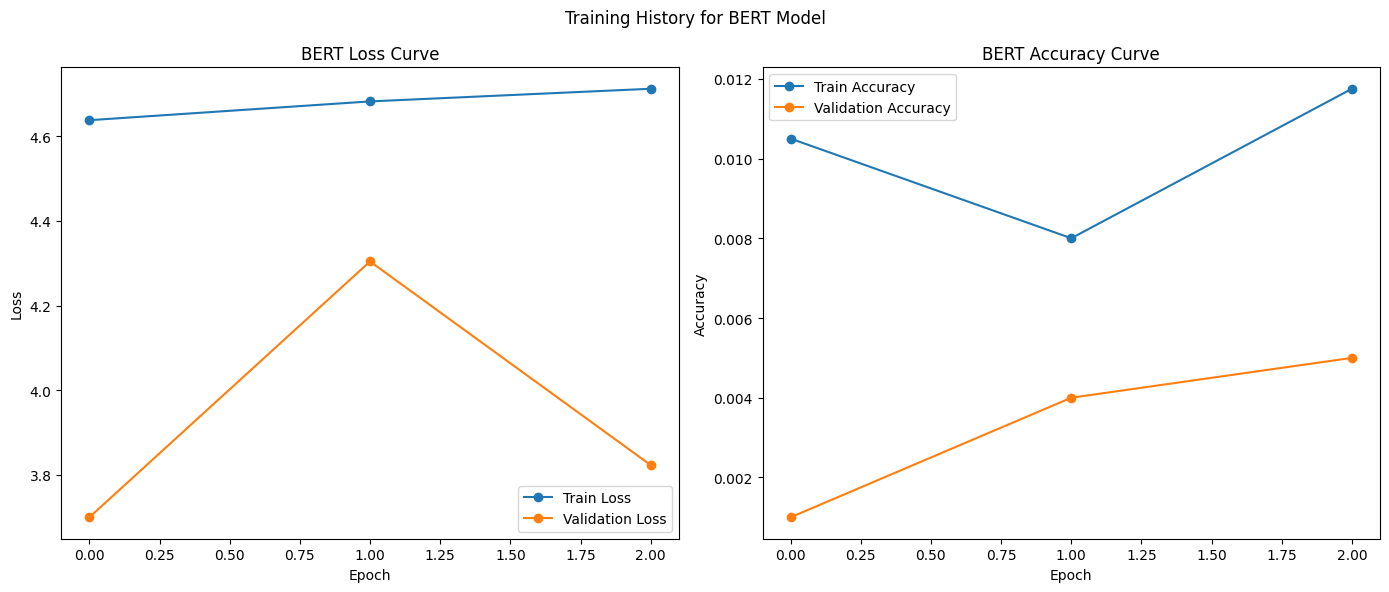


>> Evaluating model on training set...
   >> Training - Loss: 3.8281, Accuracy: 0.0055

>> Evaluating model on validation set...
   >> Validation - Loss: 3.8232, Accuracy: 0.0050

------------------------------------------------


------------------------------------------------

>> Training with BioBERT model (dmis-lab/biobert-base-cased-v1.1)

>> Initializing transformer with forced classes...


/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:382: UserWarning: The class_names argument is replacing the classes argument. Please update your code.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:850: UserWarning: Transformer models typically only support maxlen <= 512, unless you are using certain models like the Longformer.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]


>> Preprocessing training data...
preprocessing train...
language: en
train sequence lengths:
	mean : 508
	95percentile : 1076
	99percentile : 1642


...

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Is Multi-Label? False
>> Preprocessing validation data...
preprocessing test...
language: en
test sequence lengths:
	mean : 495
	95percentile : 1041
	99percentile : 1456



>> Building classifier model...


/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:1093: UserWarning: Could not load a Tensorflow version of model. (If this worked before, it might be an out-of-memory issue.) Attempting to download/load PyTorch version as TensorFlow model using from_pt=True. You will need PyTorch installed for this.
  warnings.warn(


>> Creating learner object with batch_size=6...

>> Extracting full training arrays...

>> [Extracting] Starting extraction for train_data...
>> Total batches in train_data: 667

>> Extracted train_data shapes: x: (3999, 3, 600), y: (3999, 40)

>> Extracting full validation arrays...

>> [Extracting] Starting extraction for valid_data...
>> Total batches in valid_data: 32

>> Extracted valid_data shapes: x: (1000, 3, 600), y: (1000, 40)


>> Splitting full inputs into BERT components...
   >> input_ids_train shape: (3999, 600)
   >> attention_mask_train shape: (3999, 600)
   >> token_type_ids_train shape: (3999, 600)

>> Running dummy forward pass to initialize model variables...
>> Dummy forward pass completed.

>> Training model for 3 epochs with sample weights...
Epoch 1/3
667/667 - 415s - loss: 5.7934 - accuracy: 0.0118 - val_loss: 4.1520 - val_accuracy: 0.0060 - 415s/epoch - 622ms/step
Epoch 2/3
667/667 - 398s - loss: 4.8912 - accuracy: 0.0123 - val_loss: 4.4548 - val_accuracy: 0.

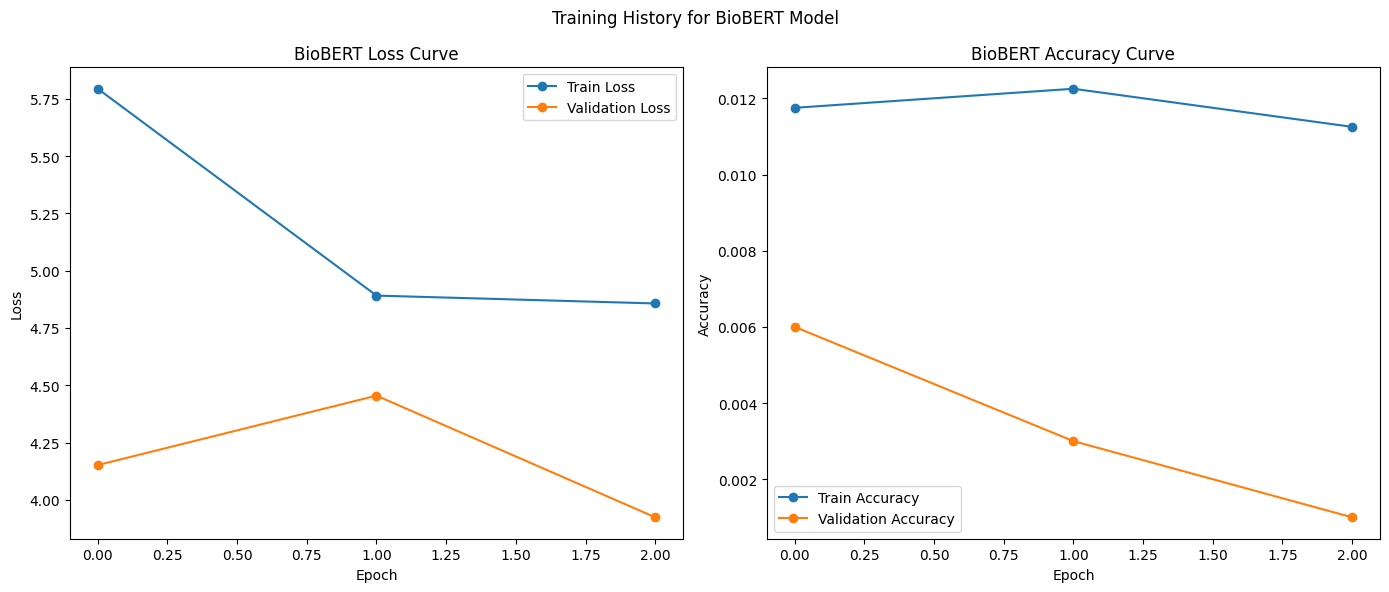


>> Evaluating model on training set...
   >> Training - Loss: 3.9249, Accuracy: 0.0018

>> Evaluating model on validation set...
   >> Validation - Loss: 3.9242, Accuracy: 0.0010

------------------------------------------------


------------------------------------------------

>> Training with SciBERT model (allenai/scibert_scivocab_uncased)

>> Initializing transformer with forced classes...


/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:382: UserWarning: The class_names argument is replacing the classes argument. Please update your code.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:850: UserWarning: Transformer models typically only support maxlen <= 512, unless you are using certain models like the Longformer.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]


>> Preprocessing training data...
preprocessing train...
language: en
train sequence lengths:
	mean : 508
	95percentile : 1076
	99percentile : 1642


...

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

Is Multi-Label? False
>> Preprocessing validation data...
preprocessing test...
language: en
test sequence lengths:
	mean : 495
	95percentile : 1041
	99percentile : 1456



>> Building classifier model...


/usr/local/lib/python3.10/dist-packages/ktrain/text/preprocessor.py:1093: UserWarning: Could not load a Tensorflow version of model. (If this worked before, it might be an out-of-memory issue.) Attempting to download/load PyTorch version as TensorFlow model using from_pt=True. You will need PyTorch installed for this.
  warnings.warn(


>> Creating learner object with batch_size=6...

>> Extracting full training arrays...

>> [Extracting] Starting extraction for train_data...
>> Total batches in train_data: 667

>> Extracted train_data shapes: x: (3999, 3, 600), y: (3999, 40)

>> Extracting full validation arrays...

>> [Extracting] Starting extraction for valid_data...
>> Total batches in valid_data: 32

>> Extracted valid_data shapes: x: (1000, 3, 600), y: (1000, 40)


>> Splitting full inputs into BERT components...
   >> input_ids_train shape: (3999, 600)
   >> attention_mask_train shape: (3999, 600)
   >> token_type_ids_train shape: (3999, 600)

>> Running dummy forward pass to initialize model variables...
>> Dummy forward pass completed.

>> Training model for 3 epochs with sample weights...
Epoch 1/3
667/667 - 416s - loss: 6.1027 - accuracy: 0.0138 - val_loss: 4.5132 - val_accuracy: 0.0200 - 416s/epoch - 624ms/step
Epoch 2/3
667/667 - 399s - loss: 4.9735 - accuracy: 0.0110 - val_loss: 4.1679 - val_accuracy: 0.

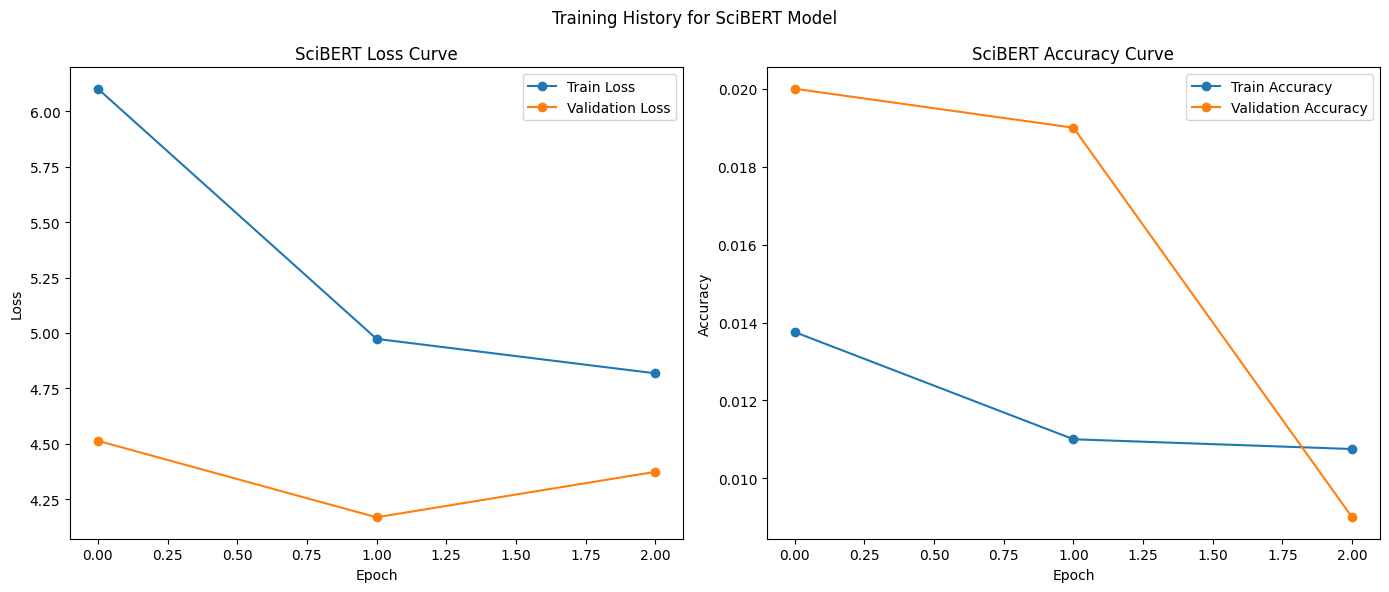


>> Evaluating model on training set...
   >> Training - Loss: 4.3729, Accuracy: 0.0095

>> Evaluating model on validation set...
   >> Validation - Loss: 4.3732, Accuracy: 0.0090

------------------------------------------------


#################### [Final Model Comparison] ####################

>> Comparison of models (Training and Validation Metrics):


,Model,Train Loss,Train Accuracy,Val Loss,Val Accuracy
0,BERT,3.828082,0.005501,3.823165,0.005
1,BioBERT,3.924878,0.001750,3.924164,0.001
2,SciBERT,4.372914,0.009502,4.373249,0.009




======== End of Modeling Pipeline for Model Comparison ========



In [11]:
print("\n\n####################  Model Comparison Loop  ####################\n")
model_list = [
    {"name": "bert-base-uncased", "label": "BERT"},
    {"name": "dmis-lab/biobert-base-cased-v1.1", "label": "BioBERT"},
    {"name": "allenai/scibert_scivocab_uncased", "label": "SciBERT"}
]

# Define number of epochs as a parameter (change this value as needed)
num_epochs = 3

results = {}

for m in model_list:
    print("\n------------------------------------------------")
    print(f"\n>> Training with {m['label']} model ({m['name']})\n")
    MODEL_NAME = m["name"]
    maxlen = 600

    print(">> Initializing transformer with forced classes...")
    t = text.Transformer(MODEL_NAME, maxlen=maxlen, classes=forced_class_names)
    
    print("\n>> Preprocessing training data...")
    train_data = t.preprocess_train(X_train, y_train_str)
    print(">> Preprocessing validation data...")
    valid_data = t.preprocess_test(X_valid, y_valid_str)
    
    print("\n>> Building classifier model...")
    model = t.get_classifier()
    print(">> Creating learner object with batch_size=6...")
    learner = ktrain.get_learner(model, train_data, valid_data, batch_size=6)
    
    print("\n>> Extracting full training arrays...")
    x_train_full, y_train_full = extract_full_data(train_data, name="train_data")
    print(">> Extracting full validation arrays...")
    x_valid_full, y_valid_full = extract_full_data(valid_data, name="valid_data")
    
    print("\n>> Splitting full inputs into BERT components...")
    input_ids_train = x_train_full[:, 0, :]
    attention_mask_train = x_train_full[:, 1, :]
    token_type_ids_train = x_train_full[:, 2, :]
    input_ids_valid = x_valid_full[:, 0, :]
    attention_mask_valid = x_valid_full[:, 1, :]
    token_type_ids_valid = x_valid_full[:, 2, :]
    print("   >> input_ids_train shape:", input_ids_train.shape)
    print("   >> attention_mask_train shape:", attention_mask_train.shape)
    print("   >> token_type_ids_train shape:", token_type_ids_train.shape)
    
    print("\n>> Running dummy forward pass to initialize model variables...")
    dummy_output = model([input_ids_train[:1],
                          attention_mask_train[:1],
                          token_type_ids_train[:1]])
    print(">> Dummy forward pass completed.\n")
    
    # Evaluate on training and validation sets after training.
    y_train_int = np.array([mapping[label.strip()] for label in train_df['medical_specialty']])
    y_train_proc = y_train_int  # Already integer labels
    sample_weights = np.array([new_class_weight_dict[int(label)] for label in y_train_proc])
    
    print(f">> Training model for {num_epochs} epochs with sample weights...")
    # Capture history to plot training curves
    history = learner.model.fit(
        [input_ids_train, attention_mask_train, token_type_ids_train],
        y_train_full,
        validation_data=([input_ids_valid, attention_mask_valid, token_type_ids_valid],
                         y_valid_full),
        epochs=num_epochs, batch_size=6, sample_weight=sample_weights, verbose=2
    )
    
    print(f"\n>> Plotting training history for {m['label']} model...")
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    # Plot Loss
    ax1.plot(history.history['loss'], label='Train Loss', marker='o')
    ax1.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    ax1.set_title(f"{m['label']} Loss Curve")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    # Plot Accuracy
    ax2.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    ax2.set_title(f"{m['label']} Accuracy Curve")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    plt.suptitle(f"Training History for {m['label']} Model")
    plt.tight_layout()
    plt.show()
    
    print("\n>> Evaluating model on training set...")
    train_eval = learner.model.evaluate(
        [input_ids_train, attention_mask_train, token_type_ids_train],
        y_train_full, verbose=0
    )
    print(f"   >> Training - Loss: {train_eval[0]:.4f}, Accuracy: {train_eval[1]:.4f}")
    
    print("\n>> Evaluating model on validation set...")
    val_eval = learner.model.evaluate(
        [input_ids_valid, attention_mask_valid, token_type_ids_valid],
        y_valid_full, verbose=0
    )
    print(f"   >> Validation - Loss: {val_eval[0]:.4f}, Accuracy: {val_eval[1]:.4f}\n")
    
    results[m["label"]] = {"Train Loss": train_eval[0], "Train Accuracy": train_eval[1],
                           "Val Loss": val_eval[0], "Val Accuracy": val_eval[1]}
    print("------------------------------------------------\n")

print("\n#################### [Final Model Comparison] ####################\n")
results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
print(">> Comparison of models (Training and Validation Metrics):")
display(results_df)
print("\n\n======== End of Modeling Pipeline for Model Comparison ========\n")
